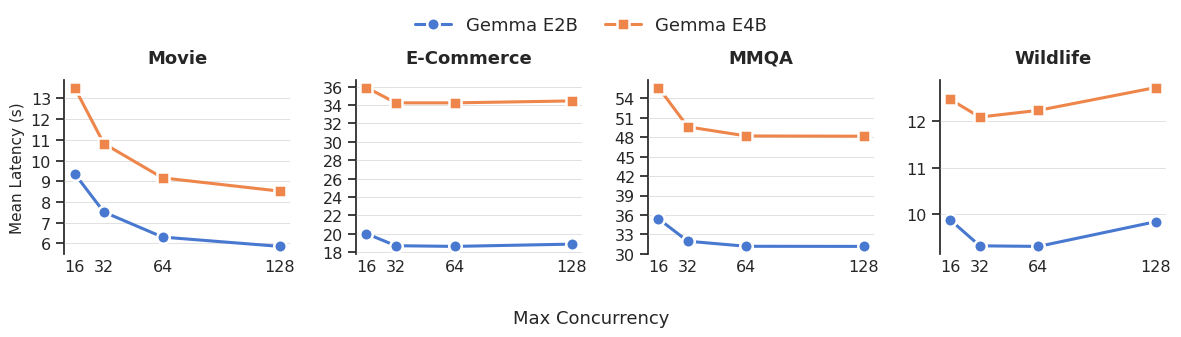

Saved.


In [11]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

tasks = ['movie', 'ecomm', 'mmqa', 'wildlife']
task_labels = {'movie': 'Movie', 'ecomm': 'E-Commerce', 'mmqa': 'MMQA', 'wildlife': 'Wildlife'}
models = ['gemma_e2b', 'gemma_e4b']
model_labels = {'gemma_e2b': 'Gemma E2B', 'gemma_e4b': 'Gemma E4B'}

MODEL_COLORS  = {'Gemma E2B': '#4878CF', 'Gemma E4B': '#EE854A'}
MODEL_MARKERS = {'Gemma E2B': 'o',       'Gemma E4B': 's'}

rows = []
for task in tasks:
    for model in models:
        path = f"../results/np_ablation/{task}/{model}/all_results_with_runs.csv"
        try:
            df = pd.read_csv(path)
            latencies = df.groupby('system_name')['latency'].mean()
            for system_name, latency in latencies.items():
                match = re.search(r'_np(\d+)_', system_name)
                if match:
                    rows.append({
                        'task': task,
                        'model': model_labels[model],
                        'num_parallel': int(match.group(1)),
                        'latency': latency,
                    })
        except FileNotFoundError:
            print(f"Warning: {path} not found, skipping.")

plot_df = pd.DataFrame(rows).sort_values('num_parallel')

# --- Styling ---
sns.set_theme(style='ticks', font_scale=1.05)
plt.rcParams.update({'font.family': 'sans-serif'})

fig, axes = plt.subplots(1, len(tasks), figsize=(12, 3), sharey=False)

for col_j, (ax, task) in enumerate(zip(axes, tasks)):
    from matplotlib.ticker import MaxNLocator
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    task_df = plot_df[plot_df['task'] == task]

    for model_name in ['Gemma E2B', 'Gemma E4B']:
        mdf = task_df[task_df['model'] == model_name].sort_values('num_parallel')
        ax.plot(
            mdf['num_parallel'], mdf['latency'],
            color=MODEL_COLORS[model_name],
            marker=MODEL_MARKERS[model_name],
            linewidth=2.2,
            markersize=9,
            markeredgewidth=1.8,
            markeredgecolor='white',
            label=model_name,
            zorder=4,
            solid_capstyle='round',
        )

    ax.set_title(task_labels[task], fontsize=13, fontweight='bold', pad=12)
    ax.set_xticks(sorted(task_df['num_parallel'].unique()))
    ax.set_ylabel('Mean Latency (s)' if col_j == 0 else '', fontsize=11)
    ax.tick_params(axis='x', length=0)

    sns.despine(ax=ax, bottom=True)
    ax.yaxis.grid(True, alpha=0.45, linewidth=0.7, color='#bbbbbb')
    ax.set_axisbelow(False)

# Legend — flat, above the figure
legend_handles = [
    mlines.Line2D(
        [], [],
        color=MODEL_COLORS[m], marker=MODEL_MARKERS[m],
        markersize=9, markeredgewidth=1.8, markeredgecolor='white',
        linewidth=2.2, label=m,
    )
    for m in ['Gemma E2B', 'Gemma E4B']
]
fig.legend(
    handles=legend_handles,
    loc='upper center',
    ncol=2,
    bbox_to_anchor=(0.5, 1.1),
    fontsize=13,
    frameon=False,
    handlelength=2,
    columnspacing=1.5,
)

fig.supxlabel('Max Concurrency', fontsize=13)
fig.tight_layout(h_pad=1.8, w_pad=1.5)
fig.savefig('../img/np_latency_plot.pdf', bbox_inches='tight')
fig.savefig('../img/np_latency_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [10]:
df1 = pd.read_csv(f"../results/np_ablation/ecomm/gemma_e4b/all_results_with_runs.csv")
df2 = pd.read_csv(f"../results/np_ablation/ecomm/gemma_e2b/all_results_with_runs.csv")

In [14]:
df1['latency'].mean()

np.float64(34.69987104034338)

In [13]:
df2['latency'].mean()

np.float64(19.064272001203904)

In [7]:
df

,Unnamed: 0,system_name,query_name,latency,gpu_usage,prediction,num_generation_calls,output_tokens,input_tokens,run,raw_metrics,quality
0,0,blendsql_np128_cftrue_eetrue,Q1,0.055990,{'samples': [{'timestamp': '2026/04/13 20:55:4...,"{""columns"":[""director""],""data"":[[""Michael Ritc...",1,3,208,0,"{'precision': 1.0, 'recall': 1.0, 'f1_score': ...",1.000000
1,1,blendsql_np128_cftrue_eetrue,Q2b,55.637079,{'samples': [{'timestamp': '2026/04/13 20:55:4...,"{""columns"":[""ID"",""local_image_path"",""color""],""...",1400,4114,548331,0,"{'precision': 0.0, 'recall': 0.0, 'f1_score': ...",0.000000
2,2,blendsql_np128_cftrue_eetrue,Q2a,47.663016,{'samples': [{'timestamp': '2026/04/13 20:56:3...,"{""columns"":[""ID"",""local_image_path""],""data"":[[...",1200,3600,472398,0,"{'precision': 0.19230769230769232, 'recall': 1...",0.322581
3,3,blendsql_np128_cftrue_eetrue,Q3a,0.859607,{'samples': [{'timestamp': '2026/04/13 20:57:2...,"{""columns"":[""title""],""data"":[[""The Interview""]...",200,600,43396,0,"{'precision': 1.0, 'recall': 0.846153846153846...",0.916667
4,4,blendsql_np128_cftrue_eetrue,Q3f,0.996618,{'samples': [{'timestamp': '2026/04/13 20:57:2...,"{""columns"":[""title""],""data"":[[""My Best Friend'...",200,600,43596,0,"{'precision': 1.0, 'recall': 1.0, 'f1_score': ...",1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
215,6,blendsql_np64_cftrue_eetrue,Q5,0.163163,{'samples': [{'timestamp': '2026/04/13 20:51:4...,"{""columns"":[""actor""],""data"":[[""Lizzy Caplan""]]}",1,5,3060,4,"{'precision': 1.0, 'recall': 1.0, 'f1_score': ...",1.000000
216,7,blendsql_np64_cftrue_eetrue,Q6b,0.527121,{'samples': [{'timestamp': '2026/04/13 20:51:4...,"{""columns"":[""Airlines""],""data"":[]}",176,528,25227,4,"{'precision': 0.0, 'recall': 0.0, 'f1_score': ...",0.000000
217,8,blendsql_np64_cftrue_eetrue,Q6c,0.653894,{'samples': [{'timestamp': '2026/04/13 20:51:4...,"{""columns"":[""Airlines""],""data"":[[""British Airw...",176,528,25227,4,"{'precision': 1.0, 'recall': 0.4, 'f1_score': ...",0.571429
218,9,blendsql_np64_cftrue_eetrue,Q6a,0.491204,{'samples': [{'timestamp': '2026/04/13 20:51:4...,"{""columns"":[""Airlines""],""data"":[[""Discover Air...",176,528,25227,4,"{'precision': 1.0, 'recall': 1.0, 'f1_score': ...",1.000000


In [5]:
plot_df.sort_values(by="model")

,task,model,num_parallel,latency,system_name
5,movie,Gemma E2B,16,9.376438,blendsql_np16_cftrue_eetrue
13,ecomm,Gemma E2B,16,20.021466,blendsql_np16_cftrue_eetrue
21,mmqa,Gemma E2B,16,35.405759,blendsql_np16_cftrue_eetrue
14,ecomm,Gemma E2B,32,18.712264,blendsql_np32_cftrue_eetrue
22,mmqa,Gemma E2B,32,31.942336,blendsql_np32_cftrue_eetrue
6,movie,Gemma E2B,32,7.518856,blendsql_np32_cftrue_eetrue
15,ecomm,Gemma E2B,64,18.638254,blendsql_np64_cftrue_eetrue
7,movie,Gemma E2B,64,6.308665,blendsql_np64_cftrue_eetrue
23,mmqa,Gemma E2B,64,31.161360,blendsql_np64_cftrue_eetrue
4,movie,Gemma E2B,128,5.858554,blendsql_np128_cftrue_eetrue


In [5]:
path

'./results/np_ablation/mmqa/gemma_e2b/all_results_with_runs.csv'

In [6]:
!ls

feature_ablation_plot.ipynb  overall_latency_quality_plot.ipynb
np-latency-plot.ipynb
